In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ação = "PETR4.SA" # análise da acao PETR4
df = yf.download(ação, start="2016-01-01", end="2026-09-16") # período 01/01/2016 - 16/09/2026
# Data Frame com as coluna Close, High, Low, Open, Volume

[*********************100%***********************]  1 of 1 completed


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 2667 entries, 2016-01-04 to 2026-09-15
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, PETR4.SA)   2667 non-null   float64
 1   (High, PETR4.SA)    2667 non-null   float64
 2   (Low, PETR4.SA)     2667 non-null   float64
 3   (Open, PETR4.SA)    2667 non-null   float64
 4   (Volume, PETR4.SA)  2667 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.0 KB


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
count,2667.000000,2667.000000,2667.000000,2667.000000,2.667000e+03
mean,13.949341,14.122416,13.773964,13.947020,5.720858e+07
std,11.608899,11.717583,11.488250,11.595870,3.318086e+07
min,1.052146,1.069682,1.032106,1.052146,0.000000e+00
25%,5.076731,5.187019,4.998856,5.086691,3.557460e+07
50%,7.879003,8.002468,7.759967,7.876268,5.025670e+07
75%,25.479664,25.744457,25.131351,25.410296,6.954880e+07
max,50.430000,50.700001,49.029999,49.509998,4.902304e+08


O Data Frame importado se refere a ação da Petrobras (PETR4) no periodo de 01/01/2016 até 16/09/2026.
As colunas do Data Frame são Close (valor da acao no fechamento da bolsa), High (pico do valor da acao no dia), Low (menor valor da acao no dia), Open (valor da acao no mometno de abertura da bolsa) e Volume (total de acoes que foram movimentadas no dia)
No Data Frame, não há nenhum informação faltante, então, podemos seguir direto para a visualizacao e manipulacao desses dados.
Nesse notebook usaremos apenas o valor de fechamento da bolsa (Close), pois queremos um resultado a longo prazo do valor da ação, nao nos interessados valores de volatilidade diaria como High e Low.

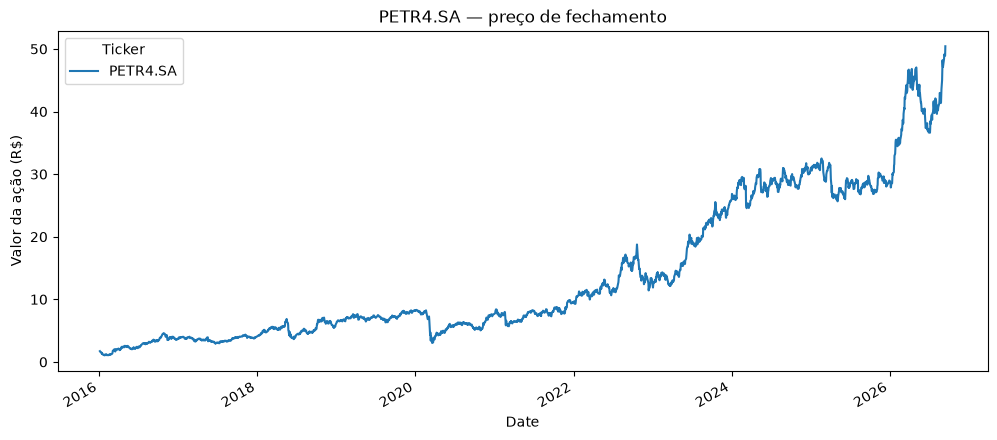

In [4]:
'''aqui plotamos uma grafico do valor da acao no periodo estudado para facilitar a visualizacao do comprotamento da acao ao longo do tempo'''
df["Close"].plot(figsize=(12,5), title=f"{ação} — preço de fechamento")
plt.ylabel("Valor da ação (R$)")
plt.show()

O gráfico acima foi inspecionado de forma visual, percebe-se que não foi visto nenhuma incoerência como saltos aburptos ou um padrão que fosse visivelmente estranho. Como já checado, não existe nenhum dado faltante, o que possibilita o prosseguimento do código sem nenhum problema.

Por esse motivo, a célula abaixo é feita para salvar esse histórico em um arquivo CSV para servir de ponto de partida do projeto. Pois assim, quando qualquer pessoa rodar o código, ela poderá atingir os mesmos resultados que veremos a seguir.

In [5]:
df.to_csv("petr4_historico.csv")

In [6]:
df["MA_curta"] = df["Close"].rolling(window=10).mean() # aqui criamos a media aritmetica curta usando os dados de fechamento (close) na janela (window) dos ultimos 20 dias, o por isso do 'rolling'
df["MA_longa"] = df["Close"].rolling(window=50).mean() # aqui é feito coisa semelhante a media aritmetica curta, porem usando os dados dos ultimos 100 dias. vale destacar que do dia 1 ao 99, nao existem 100 dias anteriores para ser feito a media do valor de fechamento, sendo assim definida como 'NaN', mesma logica se aplica a media curta

Vamos plotar em um grafico só o comportamento da ação, da media curta e da media longa nos ultimos dois anos para podermos ter uma noção mais real e precisa do comportamento das medias em relacao ao comportamento real da acao

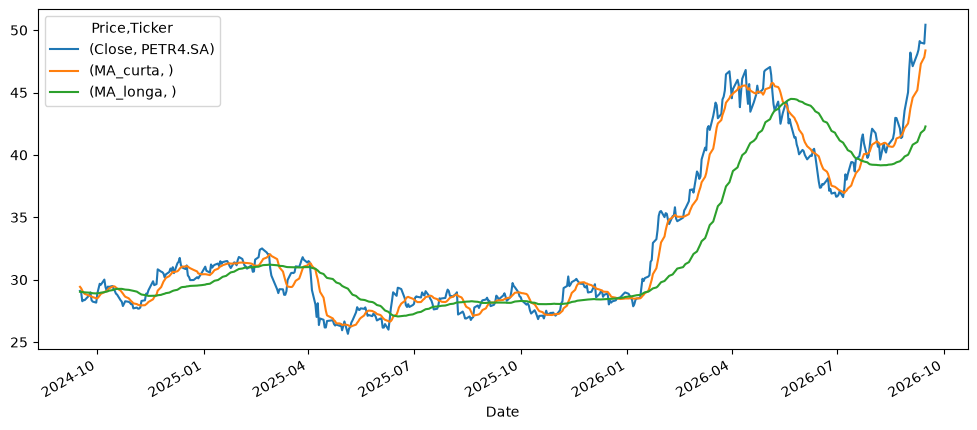

In [7]:
df.loc["2024-09-16":"2026-09-16", ["Close", "MA_curta", "MA_longa"]].plot(figsize=(12,5))
plt.show()

Olhando para o gráfico acima, percebe-se que o modelo MA crossover é ideal para momentos em que há um tendência clara de crescimento ou queda do preço da acao como é percebido no periodo de 01/26 ate 05/26. porém, nao sendo ideal para momentos de oscilacoes sem direcao definida, como visto em 09/25 ate 01/26, nesse momento acontece a oscilacao sem uma tendencia a ser seguida, gerando cruzamento de sinais que acarretam no efeito whipsaw, mostrando a fragilidade do modelo nessa situacao.

Outro topico para se ter atencao é o tamanho da janela usada no calculo da media, pois em caso do uso da quantidade de dias altos, será visto o underfitting, e, assim, quase nao consegue se ver uma relacao efetiva entre as medias e variacao diaria da acao, ja que a media é muito pouco sensivel as variacoes diarias, fazendo com que o sinal de venda ou compra chegue tarde e ocasionando na perca do timing da virada de tendencia. o mesmo ocorre para o uso de quantidade de dias pequenos para o calculo das medias, pois assim, as medias seriam quase que um espelho em relacao aos graficos devido a sua alta sensibilidade as mudancas diarias, o que o as tornariam quase inuteis, pois nao seriam capazes de prever quase nada, pois as mudancas de sinais seriam muito frequentes, tal efeito é o contrario do underfitting, conhecido como overfitting

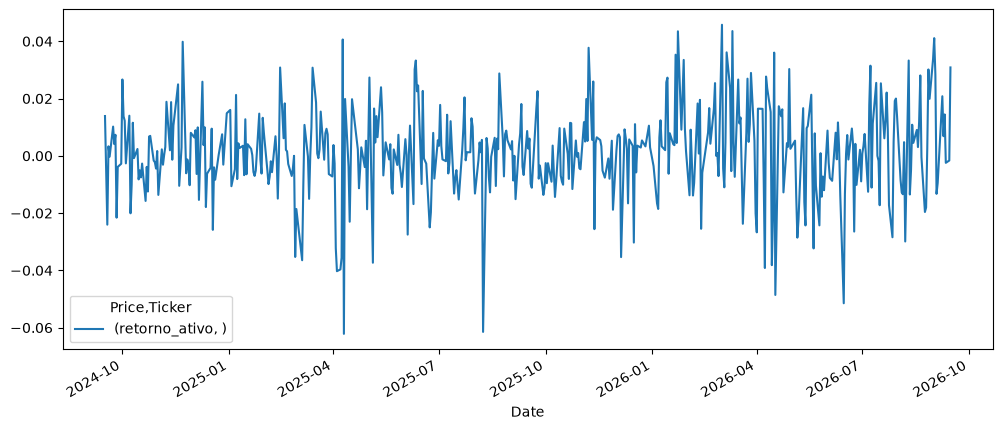

In [8]:
df["retorno_ativo"] = df["Close"].pct_change() # feito pra calcular a diferenca percentual do valor da acao entre dias consecutivos
df.loc["2024-09-16":"2026-09-16", ["retorno_ativo"]].plot(figsize=(12,5))
plt.show()

Observando o gráfico de retorno diário acima, a variação percentual da ação fica normalmente entre aproximadamente -2% e +3% na maioria dos dias, sendo uma volatilidade diária normal para a ação em destaque. Apesar disso, existem poucos dias com quedas um pouco maiores que o normal, cerca de -5% a -6%, sendo eventos reais do mercado. Além disso, o gráfico também não tem nenhuma tendência visual muito forte, uma vez que essa tendência vem da soma de muitos dias levemente positivos.

In [9]:
# aqui vamos criar a coluna 'sinal' que se refere se no momento a gente vai ter comprado ou nao a acao, sendo 0 -> nao comprada e 1 -> comprada
df["sinal"] = 0 # de inicio, coloca-se todas as linhas como 0, pois elas nao estarão compradas inicialmente
df.loc[df["MA_curta"] > df["MA_longa"], "sinal"] = 1 # é feito a condicao e do sinal, caso afirmativo, a acao é comprada
df["sinal"] = df["sinal"].shift(1) # essa linha é feita para tomar cuidado com o fato de que a media é calculada com base no valor da acao na hora do fechamento no dia D, entao, se for visto que a condicao para comprar ou vender a acao é satisfeita, essa compra ou venda so podera ser feita no dia seguinte (D + 1), assim evitando o look-ahead bias

In [10]:
'''Aqui aplicamos a estratégia de fato: multiplicamos o sinal (0 ou 1) pelo retorno do ativo daquele dia. Se a media curta for maior que a media longa (sinal de que a acao deve ser comprada ou mantê-la comprada) a estrategia pega o retorno cheio daquele dia. Em caso de média longa maior que média curta, o retorno ativo do dia é multiplicado por zero, significando que, naquele período, a acao nao deve estar comprada e, portanto, nao teve mudanca no valor da estrategia de retorno'''
df["estrategia_de_retorno"] = df["sinal"] * df["retorno_ativo"]

In [11]:
custo_por_operacao = 0.005  # vamos supor que 0,5% é o porcentagem do custo de operação definido para venda e compra de acoes
trocas = df["sinal"].diff().abs() # compara se o valor que "sinal" se refere é o mesmo da linha anterior
df["estrategia_de_retorno"] -= trocas * custo_por_operacao # quando é feito alguma operacao, é descontado um certo valor, como é feito nas corretoras

In [12]:
df["equity_estrategia"] = (1 + df["estrategia_de_retorno"]).cumprod() # retorno efetivo do usuario, apenas em momentos em que ele possui a acao
df["equity_benchmark"] = (1 + df["retorno_ativo"]).cumprod() # a nossa referencia de valor desde o momento inicial de captacao de dados

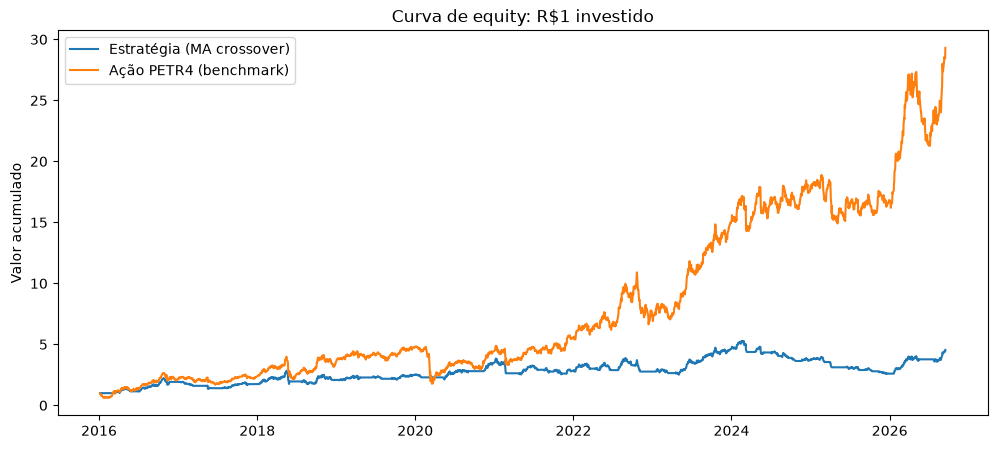

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df["equity_estrategia"], label="Estratégia (MA crossover)")
plt.plot(df["equity_benchmark"], label="Ação PETR4 (benchmark)")
plt.legend()
plt.title("Curva de equity: R$1 investido")
plt.ylabel("Valor acumulado")
plt.show()

observando o comportamento do benchmark (curva de equity) acima, percebe-se que a estratégia de MA crossover (azul) rendeu significativamente menos que o buy-and-hold da PETR4 (laranja) ao longo do período inteiro — R$1 investido virou aproximadamente R$4,50 na estratégia contra R$29 no buy-and-hold. isso provavelmente acontece porque o período analisado teve uma tendência de alta muito forte e sustentada, e qualquer estratégia que fica fora do mercado parte do tempo (como o MA crossover, que só entra depois que a média cruza) acaba perdendo uma fatia da subida em troca de proteção nos momentos de queda. some-se a isso o custo de transação, pago toda vez que o sinal muda de posição, o que também corrói o retorno ao longo de tantos anos de dados.

Outro tópico a ser comentado e mais tarde aprofundado, é que o resultado é in-sample e foi calculado numa única passada sobre o todo o histórico, o que significa que ainda nao sabemos se esse padrão de subperformance é dessa forma durante todo o tempo ou se é dessa forma nesse período em espécifico. Essa parte analisaremos melhor agora com o walk-forward validation

Portanto, agora vamos fazer o walk-forward test, usando os dados para treino (in-sample e out-of-sample), assim, podemos checar se todo o trabalho acima está válido ou não.
Abaixo vamos criar uma função (gerar_estrategia_de_retorno) utilizando boa parte das coisas que já fizemos para que possamos trenar o que ja foi feito

A função abaixo junta toda a lógica de sinal e estratégia, fazendo o cálculo das médias, geração do sinal, aplicação do retorno e desconto do custo de transação em um único bloco parametrizado pela janela curta e longa. Assim, é possível testar diferentes combinações das janelas 10/50 e 20/100 chamando a mesma função com parâmetros diferentes, em vez de fazer o código para cada combinação.

In [14]:
def gerar_estrategia_de_retorno(precos, janela_curta, janela_longa, custo=0.005):
    ma_curta = precos.rolling(janela_curta).mean()
    ma_longa = precos.rolling(janela_longa).mean()
    sinal = (ma_curta > ma_longa).astype(int).shift(1)
    retorno_ativo = precos.pct_change()
    estrategia_de_retorno = sinal * retorno_ativo
    trocas = sinal.diff().abs()
    estrategia_de_retorno -= trocas * custo
    return estrategia_de_retorno

Aqui calculamos o retorno de cada combinação em toda a série antes de entrar no loop de walk-forward. Fazemos isso por dois motivos: calcular cada média móvel de maneira separada em cada janela do walk-forward faria os primeiros dias de cada janela virarem NaN, perdendo dias que já têm dado disponível na série completa. Outro motivo, para não precisar recalcular a média móvel a cada iteração gerando baixa eficiência do código, o programa calcula a média móvel só uma vez e apenas recorta um resultado já existente.

In [15]:
'''aqui vamos usar esses dois pares de medias curtas e longas para comparar eles e ver qual par é mais efetivo para o que queremos'''

combinacoes = { 
    "10/50": gerar_estrategia_de_retorno(df["Close"].squeeze(), 10, 50), # o .squeeze() reduz a dimensao do data frame, possibilitando o prosseguimento do codigo
    "20/100": gerar_estrategia_de_retorno(df["Close"].squeeze(), 20, 100),
}

O loop abaixo implementa o walk-forward validation, que é basicamente: a cada iteração, usamos uma janela de treino (in-sample) de 600 dias para escolher, entre as combinações disponíveis, qual teve o melhor retorno acumulado nesse período. Depois disso, essa escolha é testada no período de 200 dias (out-of-sample) a seguir daquela janela de treino. Assim, é garantido que não haja look-ahead bias.

Depois de cada iteração, a janela avança pelo tamanho da janela de teste (o tamanho do out-of-sample de 200 dias), e não pela soma treino + teste (in-sample + out-of-sample). Isso garante que os períodos de teste fiquem contínuos e sem que fiquem sobrepostos entre si, então quando concatenamos todos os 'retorno_teste' no final, temos uma série out-of-sample contínua cobrindo o período entre o fim do treino inicial e o início dos dias finais que não completam uma janela. Dessa maneira, ficam de fora os primeiros 600 dias (tamanho do in-sample) e os últimos dias que nao completam uma janela de treino + teste inteira. No total, 667 dos 2667 dias do dataset não aparecem no 'retorno_walkforward'.

In [16]:
janela_treino = 600
janela_teste = 200

resultados_out_of_sample = []
escolhas = []

inicio = 0
while inicio + janela_treino + janela_teste <= len(df): # enquanto todos os dias nao foram usados em treino (in-sample ou out-of-sample)
    fim_treino = inicio + janela_treino
    fim_teste = fim_treino + janela_teste

    melhor_combo, melhor_retorno_treino = None, -float("inf")
    for nome, retorno in combinacoes.items():
        retorno_treino = (1 + retorno.iloc[inicio:fim_treino]).prod() - 1
        if retorno_treino > melhor_retorno_treino:
            melhor_retorno_treino = retorno_treino
            melhor_combo = nome

    retorno_teste = combinacoes[melhor_combo].iloc[fim_treino:fim_teste]
    resultados_out_of_sample.append(retorno_teste)
    escolhas.append(melhor_combo)

    inicio += janela_teste

retorno_walkforward = pd.concat(resultados_out_of_sample)
equity_walkforward = (1 + retorno_walkforward).cumprod()

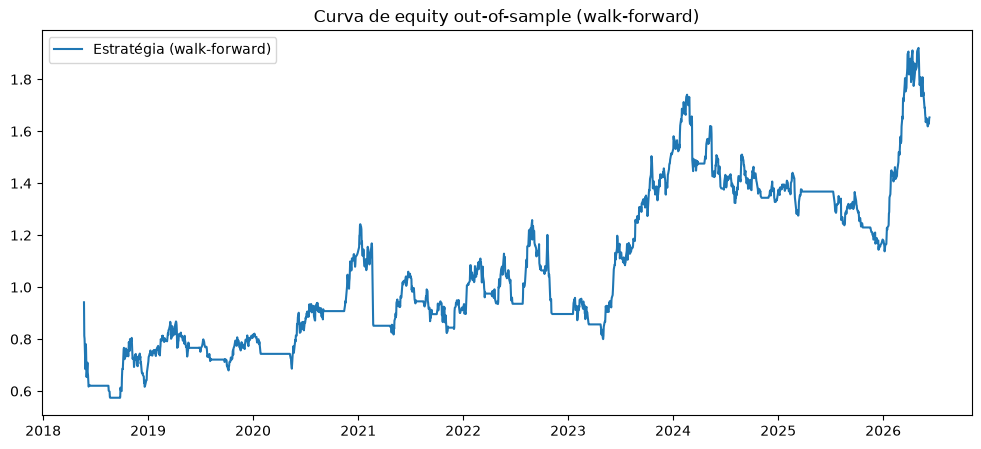

20/100    6
10/50     4
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(12,5))
plt.plot(equity_walkforward, label="Estratégia (walk-forward)")
plt.legend()
plt.title("Curva de equity out-of-sample (walk-forward)")
plt.show()

print(pd.Series(escolhas).value_counts())

Usamos o benchmark somente nas datas cobertas pelo walk-forward, pois assim é possível ter uma comparação justa entre a estrategia e o benchmark. Isso acontece porque a curva de walk-forward não cobre os primeiros 600 dias que foram usados apenas para treino inicial, então comparar com o benchmark do período todo incluiria um período onde a estratégia nunca operou.

In [18]:
retorno_benchmark_wf = df.loc[retorno_walkforward.index, "retorno_ativo"] # é a nossa referencia no periodo em que o 'retorno_walkforward' aparece, ou seja, que entraram em algum teste out-of-sample
equity_benchmark_wf = (1 + retorno_benchmark_wf).cumprod() # curva de equity no mesmo periodo

In [19]:
'''calculamos o sharpe ratio para sabermos a relacao entre o retorno-risco no periodo'''
def sharpe_ratio(retornos, dias_no_ano = 252):
    return (retornos.mean() / retornos.std()) * (dias_no_ano ** 0.5) # poderia colocar o numero direto no 'return', mas nao faremos para evitar numeros magicos no codigo

sharpe_estrategia = sharpe_ratio(retorno_walkforward) # aplicamos para a nossa estrategia
sharpe_benchmark = sharpe_ratio(retorno_benchmark_wf) # aplicamos para a nossa referencia
print(f"Sharpe estratégia: {sharpe_estrategia:.2f}")
print(f"Sharpe benchmark: {sharpe_benchmark:.2f}")

Sharpe estratégia: 0.36
Sharpe benchmark: 0.78


O Sharpe ratio é uma métrica que mede o retorno obtido em relação ao risco tomado. Nela, o retorno médio é dividido pelo desvio-padrão dos retornos, anualizado pela raiz do número de dias no ano (252). Quanto maior, melhor o retorno ajustado ao risco e mais vale o investimento na ação.

No resultado acima, a estratégia teve Sharpe de 0.36 contra 0.78 do benchmark — ou seja, o buy-and-hold (comprar a ação no início do período e nunca operar) entregou mais que o dobro de retorno por unidade de risco do que a nossa estratégia de walk-forward.

In [20]:
'''calculamos o drawdown para medirmos a queda pico a pico, assim conseguimos observar qual foi a pior queda que alguem usando a estrategia que estamos fazendo sofreu'''
def max_drawdown(equity):
    pico_acumulado = equity.cummax()
    drawdown = equity / pico_acumulado - 1 #  calcula-se o equity em relacao ao maior pico ate o momento
    return drawdown.min(), drawdown

dd_estrategia, serie_dd_estrategia = max_drawdown(equity_walkforward)
dd_benchmark, serie_dd_benchmark = max_drawdown(equity_benchmark_wf)
print(f"Máximo drawdown estratégia: {dd_estrategia:.2%}")
print(f"Máximo drawdown benchmark: {dd_benchmark:.2%}")

Máximo drawdown estratégia: -39.07%
Máximo drawdown benchmark: -63.36%


O máximo drawdown mede a pior queda percentual em relação ao pico acumulado mais alto até aquele ponto, sempre respeitando a ordem cronológica dos dados para evitar o look-ahead bias.

No resultado acima, a estratégia teve drawdown de -39.07% contra -63.36% do benchmark — a estratégia reduziu a pior perda quase pela metade, já que ficar fora do mercado em quedas fortes é justamente o que o MA crossover se propõe a fazer.

In [21]:
'''aqui vamos observar o retorno na metrica anual'''
def retorno_anualizado(equity, dias_no_ano = 252):
    n_dias = len(equity)
    return equity.iloc[-1] ** (dias_no_ano / n_dias) - 1 # pegamos o ultimo valor do equity (acumulado desde o inicio) para calcular o retorno anual

ret_anual_estrategia = retorno_anualizado(equity_walkforward) 
ret_anual_benchmark = retorno_anualizado(equity_benchmark_wf) # ref
print(f"Retorno anualizado estratégia: {ret_anual_estrategia:.2%}")
print(f"Retorno anualizado benchmark: {ret_anual_benchmark:.2%}")

Retorno anualizado estratégia: 6.54%
Retorno anualizado benchmark: 26.67%


O retorno anualizado converte o crescimento total acumulado no período em uma taxa de crescimento anual equivalente, podendo assim, comparar estratégias testadas em períodos de tamanhos diferentes numa base comum.

No resultado acima, a estratégia rendeu 6.54% ao ano contra 26.67% do benchmark — a diferença é consistente com o Sharpe e o drawdown vistos acima: a estratégia troca bastante o retorno absoluto por ter um risco menor de queda.

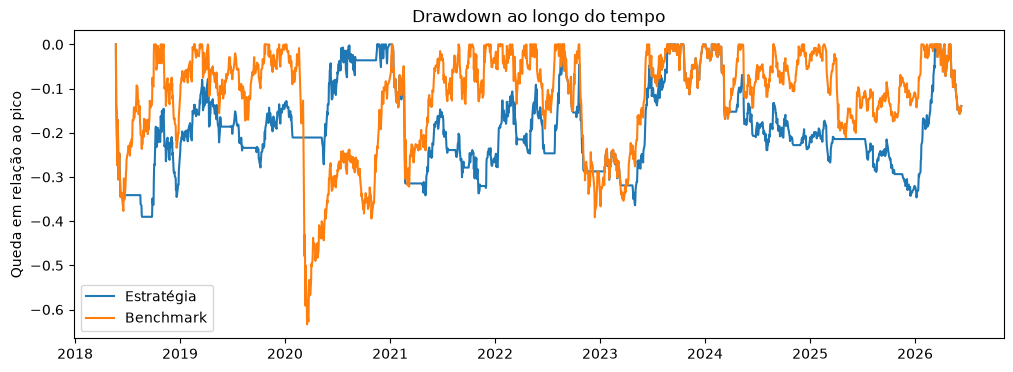

In [22]:
'''plotamos um grafico para vizualisarmos o drawdown ao longo do tempo'''
plt.figure(figsize=(12,4))
plt.plot(serie_dd_estrategia, label="Estratégia")
plt.plot(serie_dd_benchmark, label="Benchmark")
plt.legend()
plt.title("Drawdown ao longo do tempo")
plt.ylabel("Queda em relação ao pico")
plt.show()

Juntando os três números, chegamos a seguinte conclusão: a estratégia teve muito menos risco de cauda que o benchmark, podemos afirmar isso a partir do drawdown de -39.07% (estratégia) contra -63.36% (benchmark), mas para ter essa segurança vista no drawdown, tanto o retorno anualizado (6.54% da estratégia contra 26.67% do benchmark) quanto o Sharpe (0.36 da estratégia contra 0.78 do benchmark) ficaram bem abaixo do buy-and-hold.

Esse é o trade-off esperado de qualquer estratégia trend-following como o MA crossover, apesar dela reduzir a exposição durante quedas fortes, você paga esse seguro de duas formas: entra mais  atrasado nas tendências, perdendo o início do movimento, já que o sinal só surge depois que a média cruza, perdendo ponto ideal de compra e venda e também sofre com whipsaw em períodos sem direção clara, onde os cruzamentos de sinal geram operações que se cancelam. Esse trade-off só compensa quando o período analisado tem quedas realmente grandes para se proteger, o que não foi o caso da PETR4 nesses período de cerca de 10 anos, que teve uma alta excepcionalmente forte e sustentada, deixando pouco espaço pra estratégia mostrar sua vantagem de proteção.

Portanto, chega-se à conclusão de que o MA crossover é um método interessante para ações que tenham maior tendência a quedas sustentadas e prolongadas e não a quedas repentinas, já que por ela ser uma estratégia trend-following, o atraso natural das médias móveis faz a estratégia reagir tarde demais para se proteger de um crash rápido. Sua vantagem aparece quando a tendência de baixa se arrasta por tempo suficiente para o sinal reagir antes que a maior parte da perda aconteça.